# Домашнее задание: Feature Selection и PCA

## 🎯 Цели задания

1. Понять принципы анализа корреляций между признаками.

2. Освоить методы отбора признаков: Filter-метод (SelectKBest) и Wrapper-метод (RFE).

3. Изучить технику понижения размерности с помощью PCA.

4. Сравнить различные подходы и сделать выводы о их эффективности.

## 🧩 Задание

### Часть 1. Подготовка данных

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from time import perf_counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, f1_score

In [ ]:
# загрузка датасета Wine Quality
df = pd.read_csv('winequalityN.csv')
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [ ]:
# формирование задачи бинарной классификации:
# качество ≥ 7 → класс 1 (высокое качество), иначе → класс 0

df['class'] = df['quality'].map(lambda x: 1 if x >= 7 else 0)
df

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6,0
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6,0
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6,0
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,0
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,0
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6,0
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,0
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,0


In [ ]:
# удаление исходного признака quality
df = df.drop(columns='quality')
df

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,class
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,0
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,0
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,0
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,0
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,0
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,0
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,0
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,0


In [ ]:
# доля пропусков в столбцах
df.isna().mean()*100

,0
type,0.000000
fixed acidity,0.153917
volatile acidity,0.123134
citric acid,0.046175
residual sugar,0.030783
chlorides,0.030783
free sulfur dioxide,0.000000
total sulfur dioxide,0.000000
density,0.000000
pH,0.138525


*Пропуски необходимо обработать, так как с ними методы отбора признаков не будут работать. Пусть пропусков и немного, можно их не удалять, а заполнить медианой (пропуски есть только в числовых столбцах).*

In [ ]:
# заполнение пропусков медианой
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [ ]:
# разделение данных на train (70%) и test (30%) с stratify по целевой переменной

# признаки
X = df.drop(columns=['type', 'class'])
# целевая переменная
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

### Часть 2. Анализ корреляций

<Axes: >

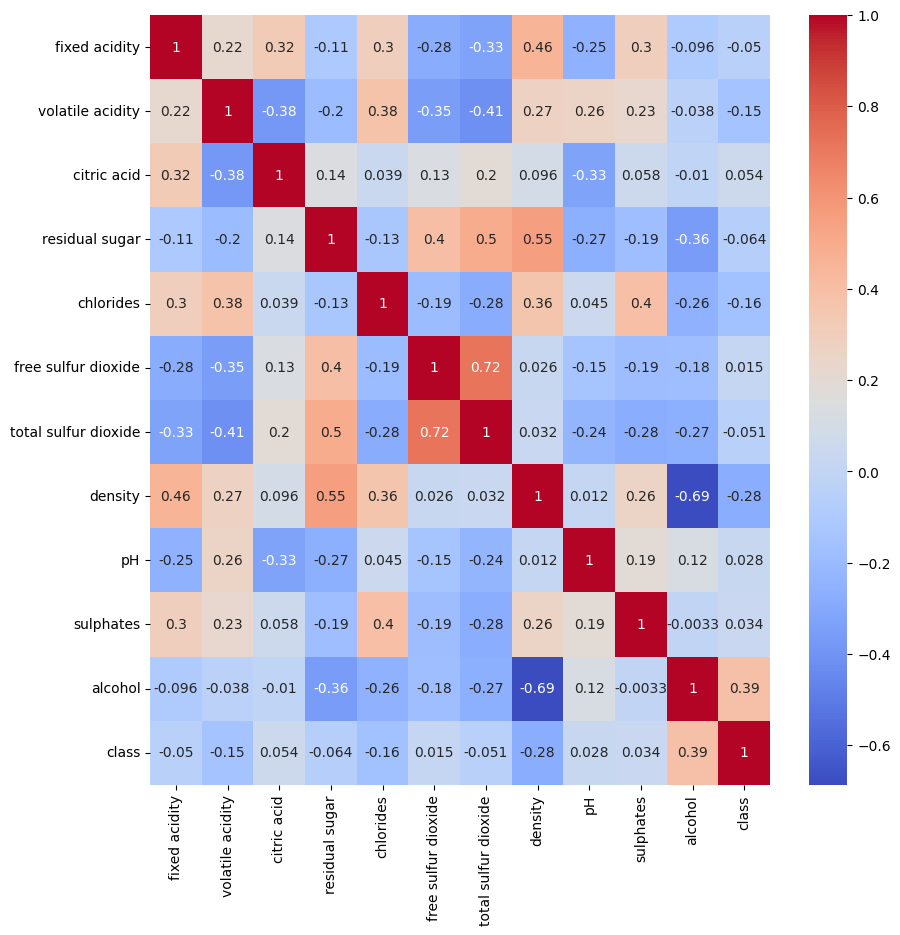

In [ ]:
# построение тепловой карты корреляций Пирсона для всех числовых признаков
corr_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

*Уже по тепловой карте видно, что сильно коррелирующих между собой пар немного*

In [ ]:
# цветная таблица
corr_matrix.style.background_gradient(
    cmap='coolwarm', axis=None
    ).format("{:.2f}")

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,class
fixed acidity,1.00,0.22,0.32,-0.11,0.30,-0.28,-0.33,0.46,-0.25,0.30,-0.10,-0.05
volatile acidity,0.22,1.00,-0.38,-0.20,0.38,-0.35,-0.41,0.27,0.26,0.23,-0.04,-0.15
citric acid,0.32,-0.38,1.00,0.14,0.04,0.13,0.20,0.10,-0.33,0.06,-0.01,0.05
residual sugar,-0.11,-0.20,0.14,1.00,-0.13,0.40,0.50,0.55,-0.27,-0.19,-0.36,-0.06
chlorides,0.30,0.38,0.04,-0.13,1.00,-0.19,-0.28,0.36,0.04,0.40,-0.26,-0.16
free sulfur dioxide,-0.28,-0.35,0.13,0.40,-0.19,1.00,0.72,0.03,-0.15,-0.19,-0.18,0.01
total sulfur dioxide,-0.33,-0.41,0.20,0.50,-0.28,0.72,1.00,0.03,-0.24,-0.28,-0.27,-0.05
density,0.46,0.27,0.10,0.55,0.36,0.03,0.03,1.00,0.01,0.26,-0.69,-0.28
pH,-0.25,0.26,-0.33,-0.27,0.04,-0.15,-0.24,0.01,1.00,0.19,0.12,0.03
sulphates,0.30,0.23,0.06,-0.19,0.40,-0.19,-0.28,0.26,0.19,1.00,-0.00,0.03


In [ ]:
# поиск пар признаков с |корреляция| > 0.7

strong_corr_pairs = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    ).stack()
strong_corr_pairs = strong_corr_pairs[abs(strong_corr_pairs) > 0.7]

print('Пары признаков с сильной взаимной корреляцией (> 0.7 по модулю):')
print(strong_corr_pairs)

Пары признаков с сильной взаимной корреляцией (> 0.7 по модулю):
free sulfur dioxide  total sulfur dioxide    0.720934
dtype: float64


**Почему такие признаки могут ухудшать модель:**

*Сильно коррелирующие между собой признаки приводят к избыточности данных и повышают мультиколлинеарность. Что может привести к переобучению модели (модель покажет хорошие результаты на обучающей выборке, но плохие - на новых данных), замедлению обучения, модель может оказаться нестабильной и ненадежной, она будет путаться в этих сильнокоррелирующих между собой признаках.*

**В данной задаче выявлена одна сильно коррелирующая пара признаков.**

In [ ]:
# удаление признака free sulfur dioxide из сильно коррелирующей пары
# (у признака total sulfur dioxide корреляция с таргетом выше)

X_train = X_train.drop(columns=['free sulfur dioxide'])
X_test = X_test.drop(columns=['free sulfur dioxide'])

### Часть 3. Filter-методы отбора

In [ ]:
# применение SelectKBest для отбора топ-5 признаков

start_kbest = perf_counter()

# создание селектора для отбора
selector_kbest = SelectKBest(score_func=f_classif, k=5)
# обучение селектора на обучающей выборке
X_train_kbest = selector_kbest.fit_transform(X_train, y_train)
# применение селектора к тестовой выборке
X_test_kbest = selector_kbest.transform(X_test)

elapsed_kbest = perf_counter() - start_kbest

# проверка размерностей
print(f'X_train до отбора: {X_train.shape}, после: {X_train_kbest.shape}')
print(f'X_test до отбора: {X_test.shape}, после: {X_test_kbest.shape}')

# какие признаки были выбраны
selected_features_kbest = selector_kbest.get_feature_names_out()
print(f'Выбранные признаки: {selected_features_kbest.tolist()}')

X_train до отбора: (4547, 10), после: (4547, 5)
X_test до отбора: (1950, 10), после: (1950, 5)
Выбранные признаки: ['volatile acidity', 'residual sugar', 'chlorides', 'density', 'alcohol']


In [ ]:
# обучение логистической регрессии на отобранных признаках
log_regr_kbest = LogisticRegression(max_iter=5000, random_state=42)
log_regr_kbest.fit(X_train_kbest, y_train)

LogisticRegression(max_iter=5000, random_state=42)

In [ ]:
# оценка ROC-AUC на тестовой выборке
y_pred__kbest_proba = log_regr_kbest.predict_proba(X_test_kbest)[:, 1]

roc_auc_kbest = roc_auc_score(y_test, y_pred__kbest_proba)
print(f'ROC-AUC после применения SelectKBest: {roc_auc_kbest:.4f}')

ROC-AUC после применения SelectKBest: 0.7918


### Часть 4. Wrapper метод (RFE)

In [ ]:
# применение RFE с логистической регрессией в качестве оценивающей модели
# для отбора 5 признаков

start_rfe = perf_counter()

# создание селектора для отбора
selector_rfe = RFE(
    estimator=LogisticRegression(max_iter=5000, random_state=42),
    n_features_to_select=5
    )
# обучение селектора на обучающей выборке
X_train_rfe = selector_rfe.fit_transform(X_train, y_train)
# применение селектора к тестовой выборке
X_test_rfe = selector_rfe.transform(X_test)

elapsed_rfe = perf_counter() - start_rfe

# проверка размерностей
print(f'X_train до отбора: {X_train.shape}, после: {X_train_rfe.shape}')
print(f'X_test до отбора: {X_test.shape}, после: {X_test_rfe.shape}')

# какие признаки были выбраны
selected_features_rfe = selector_rfe.get_feature_names_out()
print(f'Выбранные признаки: {selected_features_rfe.tolist()}')

X_train до отбора: (4547, 10), после: (4547, 5)
X_test до отбора: (1950, 10), после: (1950, 5)
Выбранные признаки: ['volatile acidity', 'chlorides', 'pH', 'sulphates', 'alcohol']


In [ ]:
# обучение логистической регрессии на отобранных признаках
log_regr_rfe = LogisticRegression(max_iter=5000, random_state=42)
log_regr_rfe.fit(X_train_rfe, y_train)

LogisticRegression(max_iter=5000, random_state=42)

In [ ]:
# оценка ROC-AUC на тестовой выборке
y_pred_rfe_proba = log_regr_rfe.predict_proba(X_test_rfe)[:, 1]

roc_auc_rfe = roc_auc_score(y_test, y_pred_rfe_proba)
print(f'ROC-AUC после применения RFE: {roc_auc_rfe:.4f}')

ROC-AUC после применения RFE: 0.7937


In [ ]:
# сравнение набора признаков, отобранных через SelectKBest и RFE

print(
    f'Выбранные методом SelectKBest признаки:\n'
    f'{sorted(selected_features_kbest.tolist())}'
    )
print(
    f'\nВыбранные методом RFE признаки:\n'
    f'{sorted(selected_features_rfe.tolist())}'
    )
print(
    f'\nОбщие для методов признаки:\n'
    f'{sorted(set(selected_features_kbest) & set(selected_features_rfe))}'
    )
print(
    f'\nПризнаки только в SelectKBest:\n'
    f'{sorted(set(selected_features_kbest) - set(selected_features_rfe))}'
    )
print(
    f'\nПризнаки только в RFE:\n'
    f'{sorted(set(selected_features_rfe) - set(selected_features_kbest))}'
    )

Выбранные методом SelectKBest признаки:
['alcohol', 'chlorides', 'density', 'residual sugar', 'volatile acidity']

Выбранные методом RFE признаки:
['alcohol', 'chlorides', 'pH', 'sulphates', 'volatile acidity']

Общие для методов признаки:
['alcohol', 'chlorides', 'volatile acidity']

Признаки только в SelectKBest:
['density', 'residual sugar']

Признаки только в RFE:
['pH', 'sulphates']


**Объяснение различий в отборе признаков методами SelectKBest и RFE.**

Различия объясняются различием в алгоритмах отбора:

* SelectKBest выбирает каждый признак по статистическому критерию, оценивая при этом признаки по их вкладу в результат модели по одному;
* RFE же рекурсивно удаляет наименее важные признаки, каждый раз переобучивая модель, при этом оценивает вклад конкретного набора признаков в контексте конкретной модели.

### Часть 5. Преобразование признаков (PCA)

In [ ]:
# применение StandardScaler к данным(обязательно перед PCA!)
# к train применяется fit_transform, для test - transform для предотвращения
# утечки данных
scaler_pca = StandardScaler()
X_train_scaled = scaler_pca.fit_transform(X_train)
X_test_scaled = scaler_pca.transform(X_test)

# реализация метода PCA
pca = PCA(random_state=42)
pca.fit(X_train_scaled)

PCA(random_state=42)

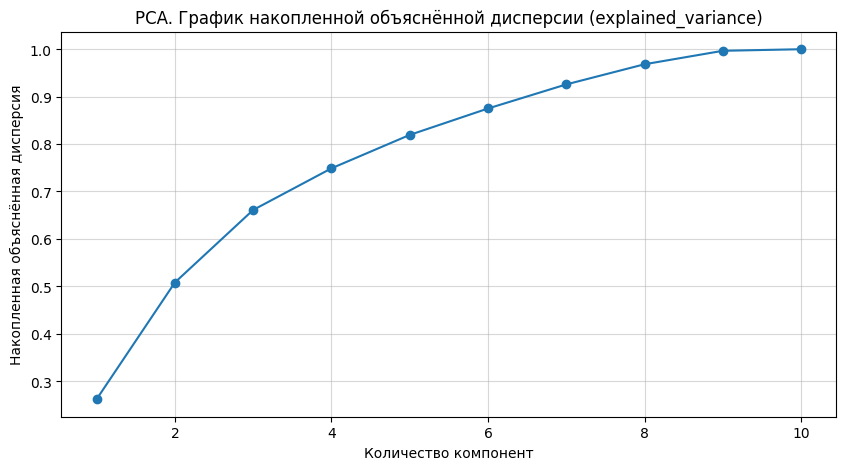

In [ ]:
# построение графика накопленной объяснённой дисперсии для компонент от 1 до 10
# накопленная доля объяснённой дисперсии
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10,5))
plt.plot(np.arange(1, len(cum_var) + 1), cum_var, marker='o')
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная объяснённая дисперсия')
plt.title('PCA. График накопленной объяснённой дисперсии (explained_variance)')
plt.grid(alpha=0.5)

plt.show()

In [ ]:
# определение минимального числа компонент, объясняющих ≥ 90% дисперсии
n_comp_var90 = int(np.searchsorted(cum_var, 0.9) + 1)
print(
    f'Минимальное число компонент, объясняющих ≥ 90% дисперсии: '
    f'{n_comp_var90}'
    )

Минимальное число компонент, объясняющих ≥ 90% дисперсии: 7


In [ ]:
# обучение логистической регрессии на полученных компонентах

start_pca = perf_counter()

pca_final = PCA(n_components=n_comp_var90, random_state=42)

X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

elapsed_pca = perf_counter() - start_pca

model_pca = LogisticRegression(max_iter=5000, random_state=42)
model_pca.fit(X_train_pca, y_train)

LogisticRegression(max_iter=5000, random_state=42)

In [ ]:
# оценка ROC-AUC на тестовой выборке
y_pred_pca_proba = model_pca.predict_proba(X_test_pca)[:, 1]

roc_auc_pca = roc_auc_score(y_test, y_pred_pca_proba)
print(f'ROC-AUC после применения PCA: {roc_auc_pca:.4f}')

ROC-AUC после применения PCA: 0.7915


In [ ]:
# сравнение ROC-AUC разных методов
print('Полученные значение метрики ROC-AUC:')
print(f'В методе SelectKBest ------ {roc_auc_kbest:.4f}')
print(f'В методе RFE -------------- {roc_auc_rfe:.4f}')
print(f'В методе PCA -------------- {roc_auc_pca:.4f}')

Полученные значение метрики ROC-AUC:
В методе SelectKBest ------ 0.7918
В методе RFE -------------- 0.7937
В методе PCA -------------- 0.7915


In [ ]:
# сравнение скорости работы методов по отбору признаков
print('Время работы методов по отбору признаков:')
print(f'SelectKBest: -------------- {elapsed_kbest:.6f} сек')
print(f'RFE: ---------------------- {elapsed_rfe:.6f} сек')
print(f'PCA: ---------------------- {elapsed_pca:.6f} сек')

Время работы методов по отбору признаков:
SelectKBest: -------------- 0.013856 сек
RFE: ---------------------- 2.605886 сек
PCA: ---------------------- 0.003151 сек


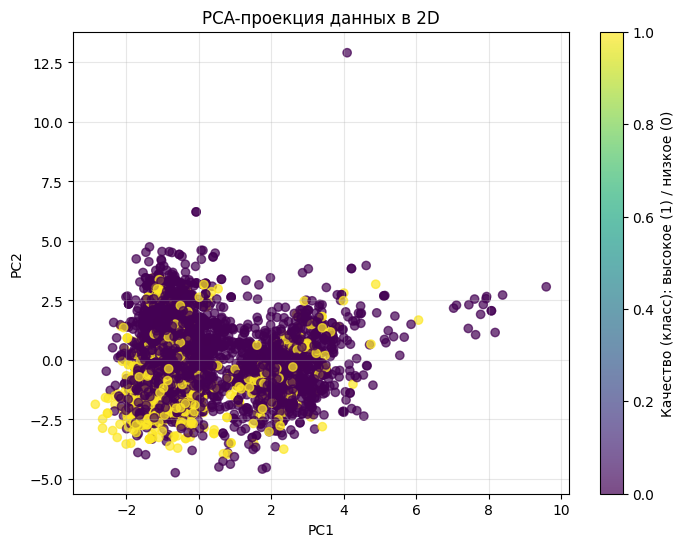

In [ ]:
# визуализация данных в пространстве первых двух главных компонент
# раскрашивание точек по целевому классу

pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train_scaled)

# scatter-диаграмма: точки окрашены по классу
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA-проекция данных в 2D')
plt.grid(alpha=0.3)
plt.colorbar(scatter, label='Качество (класс): высокое (1) / низкое (0)')

plt.show()

*По данной визуализации видно, что классы 0 и 1 заметно перекрываются и не образуют чётко разделённых групп, что нет однозначного разделения ни по оси PC1, ни по оси PC2. Видимо, это связано с тем, что PCA снижает размерность данных без учёта целевой переменной и сохраняет направления максимальной дисперсии признаков, а не направления, которые лучше всего разделяют классы. При этом полезным является то, что первые две главные компоненты позволяют компактно представить структуру данных и выявить общие закономерности распределения объектов.*

## 📝 Выводы

Сформулируйте общий вывод:  
Какой подход показал лучший баланс между качеством, скоростью и интерпретируемостью?

*В данной задаче лучший баланс между качеством, скоростью и интерпретируемостью показал метод `RFE`, поэтому его можно считать наиболее предпочтительным подходом.*


1.   *Качество: лучший результат по ROC-AUC = 0.7937*
2.   *Скорость: ощутимо ниже других методов, но для анализируемого датасета приемлема*
3.   *Интерпретируемость: сохраняет исходные признаки и позволяет понять, какие характеристики вина действительно важны для классификации*



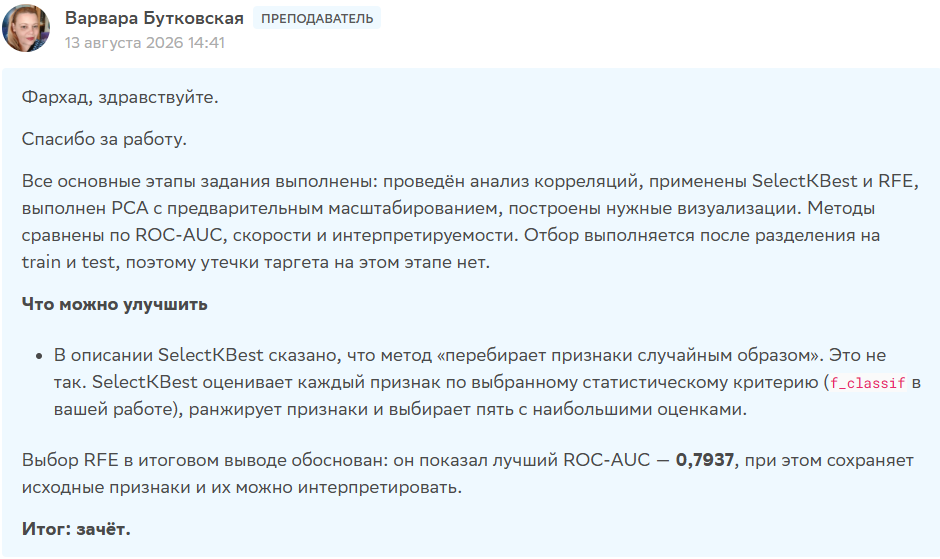